# 1

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

ImageFile.LOAD_TRUNCATED_IMAGES = True

# 2

In [2]:
BASE_DIR = Path(r"C:\Users\Hoannd\Downloads\data_face")
UTK_ROOT = BASE_DIR / "UTK_data"

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

OUT_DIR = BASE_DIR / "face_attribute_work"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("UTK_ROOT:", UTK_ROOT, UTK_ROOT.exists())
print("MODEL_DIR:", MODEL_DIR)
print("OUT_DIR:", OUT_DIR)

UTK_ROOT: C:\Users\Hoannd\Downloads\data_face\UTK_data True
MODEL_DIR: C:\Users\Hoannd\Downloads\data_face\models
OUT_DIR: C:\Users\Hoannd\Downloads\data_face\face_attribute_work


# 3

In [3]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []

for img_path in UTK_ROOT.rglob("*"):
    if img_path.is_file() and img_path.suffix.lower() in IMAGE_EXTS:
        records.append({
            "path": str(img_path),
            "filename": img_path.name,
            "parent": img_path.parent.name,
            "relative_path": str(img_path.relative_to(UTK_ROOT))
        })

df_files = pd.DataFrame(records)

print("Tổng ảnh tìm thấy:", len(df_files))
display(df_files.head(20))
display(df_files["parent"].value_counts().head(20))

Tổng ảnh tìm thấy: 66976


,path,filename,parent,relative_path
0,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,100_1_0_20170110183726390.jpg.chip.jpg,crop_part1,crop_part1\100_1_0_20170110183726390.jpg.chip.jpg
1,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,100_1_2_20170105174847679.jpg.chip.jpg,crop_part1,crop_part1\100_1_2_20170105174847679.jpg.chip.jpg
2,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,101_1_2_20170105174739309.jpg.chip.jpg,crop_part1,crop_part1\101_1_2_20170105174739309.jpg.chip.jpg
3,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,10_0_0_20161220222308131.jpg.chip.jpg,crop_part1,crop_part1\10_0_0_20161220222308131.jpg.chip.jpg
4,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,10_0_0_20170103200329407.jpg.chip.jpg,crop_part1,crop_part1\10_0_0_20170103200329407.jpg.chip.jpg
5,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,10_0_0_20170103200522151.jpg.chip.jpg,crop_part1,crop_part1\10_0_0_20170103200522151.jpg.chip.jpg
6,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,10_0_0_20170103233459275.jpg.chip.jpg,crop_part1,crop_part1\10_0_0_20170103233459275.jpg.chip.jpg
7,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,10_0_0_20170104013211746.jpg.chip.jpg,crop_part1,crop_part1\10_0_0_20170104013211746.jpg.chip.jpg
8,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,10_0_0_20170110215927291.jpg.chip.jpg,crop_part1,crop_part1\10_0_0_20170110215927291.jpg.chip.jpg
9,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,10_0_0_20170110220033115.jpg.chip.jpg,crop_part1,crop_part1\10_0_0_20170110220033115.jpg.chip.jpg


parent
UTKFace       47416
crop_part1    19560
Name: count, dtype: int64

# 4

In [4]:
def parse_utk_filename(filename):
    """
    Parse filename UTKFace.
    Expected:
    age_gender_race_date.jpg
    
    Return:
    age, gender
    """
    stem = Path(filename).stem
    parts = stem.split("_")
    
    if len(parts) < 2:
        return None
    
    try:
        age = int(parts[0])
        gender = int(parts[1])
    except Exception:
        return None
    
    if age < 0 or age > 120:
        return None
    
    if gender not in [0, 1]:
        return None
    
    return age, gender


parsed_records = []

for row in df_files.itertuples():
    parsed = parse_utk_filename(row.filename)
    
    if parsed is None:
        continue
    
    age, gender = parsed
    
    parsed_records.append({
        "path": row.path,
        "filename": row.filename,
        "parent": row.parent,
        "relative_path": row.relative_path,
        "age": age,
        "gender": gender
    })

df = pd.DataFrame(parsed_records)

print("Ảnh parse được nhãn:", len(df))
display(df.head())
display(df[["age", "gender"]].describe())
display(df["gender"].value_counts())

Ảnh parse được nhãn: 66974


,path,filename,parent,relative_path,age,gender
0,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,100_1_0_20170110183726390.jpg.chip.jpg,crop_part1,crop_part1\100_1_0_20170110183726390.jpg.chip.jpg,100,1
1,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,100_1_2_20170105174847679.jpg.chip.jpg,crop_part1,crop_part1\100_1_2_20170105174847679.jpg.chip.jpg,100,1
2,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,101_1_2_20170105174739309.jpg.chip.jpg,crop_part1,crop_part1\101_1_2_20170105174739309.jpg.chip.jpg,101,1
3,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,10_0_0_20161220222308131.jpg.chip.jpg,crop_part1,crop_part1\10_0_0_20161220222308131.jpg.chip.jpg,10,0
4,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,10_0_0_20170103200329407.jpg.chip.jpg,crop_part1,crop_part1\10_0_0_20170103200329407.jpg.chip.jpg,10,0


,age,gender
count,66974.000000,66974.000000
mean,32.168931,0.499418
std,21.502060,0.500003
min,1.000000,0.000000
25%,18.000000,0.000000
50%,28.000000,0.000000
75%,45.000000,1.000000
max,116.000000,1.000000


gender
0    33526
1    33448
Name: count, dtype: int64

# 5

In [5]:
def age_to_group(age):
    if age <= 12:
        return "child"
    elif age <= 19:
        return "teen"
    elif age <= 39:
        return "adult"
    elif age <= 59:
        return "middle_age"
    else:
        return "senior"


age_group_order = ["child", "teen", "adult", "middle_age", "senior"]
age_group_to_idx = {name: idx for idx, name in enumerate(age_group_order)}
idx_to_age_group = {idx: name for name, idx in age_group_to_idx.items()}

gender_to_label = {
    0: "male",
    1: "female"
}

df["age_group"] = df["age"].apply(age_to_group)
df["age_group_idx"] = df["age_group"].map(age_group_to_idx)
df["gender_label"] = df["gender"].map(gender_to_label)

display(df["age_group"].value_counts())
display(df["gender_label"].value_counts())
display(df.head())

age_group
adult         28864
child         13336
middle_age    12314
senior         8282
teen           4178
Name: count, dtype: int64

gender_label
male      33526
female    33448
Name: count, dtype: int64

,path,filename,parent,relative_path,age,gender,age_group,age_group_idx,gender_label
0,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,100_1_0_20170110183726390.jpg.chip.jpg,crop_part1,crop_part1\100_1_0_20170110183726390.jpg.chip.jpg,100,1,senior,4,female
1,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,100_1_2_20170105174847679.jpg.chip.jpg,crop_part1,crop_part1\100_1_2_20170105174847679.jpg.chip.jpg,100,1,senior,4,female
2,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,101_1_2_20170105174739309.jpg.chip.jpg,crop_part1,crop_part1\101_1_2_20170105174739309.jpg.chip.jpg,101,1,senior,4,female
3,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,10_0_0_20161220222308131.jpg.chip.jpg,crop_part1,crop_part1\10_0_0_20161220222308131.jpg.chip.jpg,10,0,child,0,male
4,C:\Users\Hoannd\Downloads\data_face\UTK_data\c...,10_0_0_20170103200329407.jpg.chip.jpg,crop_part1,crop_part1\10_0_0_20170103200329407.jpg.chip.jpg,10,0,child,0,male


# 6

In [6]:
print("Trước bỏ trùng:", len(df))

df = df.drop_duplicates(subset=["filename"]).copy()
df = df.reset_index(drop=True)

print("Sau bỏ trùng filename:", len(df))
display(df["parent"].value_counts())

Trước bỏ trùng: 66974
Sau bỏ trùng filename: 23708


parent
UTKFace       13929
crop_part1     9779
Name: count, dtype: int64

# 7

In [7]:
MAX_SAMPLES = None  # để None dùng toàn bộ, hoặc đặt 15000 nếu muốn nhanh

if MAX_SAMPLES is not None and len(df) > MAX_SAMPLES:
    df = df.sample(MAX_SAMPLES, random_state=42).reset_index(drop=True)

print("Tổng ảnh dùng train:", len(df))
display(df.groupby(["age_group", "gender_label"]).size().reset_index(name="count"))

Tổng ảnh dùng train: 23708


,age_group,gender_label,count
0,adult,female,6342
1,adult,male,5539
2,child,female,1806
3,child,male,1607
4,middle_age,female,1366
5,middle_age,male,3178
6,senior,female,1144
7,senior,male,1546
8,teen,female,659
9,teen,male,521


# 8

In [8]:
df["stratify_col"] = df["age_group"] + "_" + df["gender"].astype(str)

# loại những nhóm quá ít mẫu để tránh lỗi stratify
counts = df["stratify_col"].value_counts()
valid_groups = counts[counts >= 3].index

df_clean = df[df["stratify_col"].isin(valid_groups)].copy()
df_clean = df_clean.reset_index(drop=True)

print("Sau lọc nhóm ít mẫu:", len(df_clean))

df_train, df_tmp = train_test_split(
    df_clean,
    test_size=0.30,
    random_state=42,
    stratify=df_clean["stratify_col"]
)

df_val, df_test = train_test_split(
    df_tmp,
    test_size=0.50,
    random_state=42,
    stratify=df_tmp["stratify_col"]
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("Train:", len(df_train))
print("Val:", len(df_val))
print("Test:", len(df_test))

display(df_train["age_group"].value_counts())
display(df_val["age_group"].value_counts())
display(df_test["age_group"].value_counts())

Sau lọc nhóm ít mẫu: 23708
Train: 16595
Val: 3556
Test: 3557


age_group
adult         8316
middle_age    3181
child         2389
senior        1883
teen           826
Name: count, dtype: int64

age_group
adult         1782
middle_age     681
child          512
senior         404
teen           177
Name: count, dtype: int64

age_group
adult         1783
middle_age     682
child          512
senior         403
teen           177
Name: count, dtype: int64

# 9

In [9]:
df_train.to_csv(OUT_DIR / "attr_train.csv", index=False, encoding="utf-8-sig")
df_val.to_csv(OUT_DIR / "attr_val.csv", index=False, encoding="utf-8-sig")
df_test.to_csv(OUT_DIR / "attr_test.csv", index=False, encoding="utf-8-sig")

print("Saved:")
print(OUT_DIR / "attr_train.csv")
print(OUT_DIR / "attr_val.csv")
print(OUT_DIR / "attr_test.csv")

Saved:
C:\Users\Hoannd\Downloads\data_face\face_attribute_work\attr_train.csv
C:\Users\Hoannd\Downloads\data_face\face_attribute_work\attr_val.csv
C:\Users\Hoannd\Downloads\data_face\face_attribute_work\attr_test.csv


# 10

In [10]:
class UTKAttributeDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = Path(row["path"])
        
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (224, 224), color=(0, 0, 0))
        
        if self.transform:
            img = self.transform(img)
        
        gender = torch.tensor(int(row["gender"]), dtype=torch.long)
        age_group = torch.tensor(int(row["age_group_idx"]), dtype=torch.long)
        
        # Tuổi cụ thể. Normalize về 0-1 để regression dễ học hơn.
        age = torch.tensor(float(row["age"]) / 100.0, dtype=torch.float32)
        
        return img, {
            "gender": gender,
            "age_group": age_group,
            "age": age
        }

# 11

In [11]:
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 12

In [12]:
BATCH_SIZE = 32
NUM_WORKERS = 0

train_ds = UTKAttributeDataset(df_train, transform=train_tfms)
val_ds = UTKAttributeDataset(df_val, transform=eval_tfms)
test_ds = UTKAttributeDataset(df_test, transform=eval_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 519
Val batches: 112
Test batches: 112


# 13

In [13]:
class FaceAttributeModel(nn.Module):
    def __init__(self, num_age_groups=5, num_genders=2):
        super().__init__()
        
        base = models.mobilenet_v3_small(
            weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
        )
        
        self.features = base.features
        self.avgpool = base.avgpool
        
        in_features = base.classifier[0].in_features
        
        self.shared = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.Hardswish(),
            nn.Dropout(p=0.2),
        )
        
        self.gender_head = nn.Linear(512, num_genders)
        self.age_group_head = nn.Linear(512, num_age_groups)
        
        # Output tuổi dạng số normalized 0-1
        self.age_head = nn.Linear(512, 1)
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        
        x = self.shared(x)
        
        gender_logits = self.gender_head(x)
        age_group_logits = self.age_group_head(x)
        age_pred = self.age_head(x).squeeze(1)
        
        return {
            "gender": gender_logits,
            "age_group": age_group_logits,
            "age": age_pred
        }


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FaceAttributeModel(
    num_age_groups=len(age_group_order),
    num_genders=2
).to(device)

print("Device:", device)
print(model)

Device: cpu
FaceAttributeModel(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, k

# 14

In [14]:
criterion_gender = nn.CrossEntropyLoss()
criterion_age_group = nn.CrossEntropyLoss()

# Regression tuổi
criterion_age = nn.SmoothL1Loss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

# 15

In [15]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    
    total_loss = 0.0
    
    gender_true = []
    gender_pred = []
    
    age_group_true = []
    age_group_pred = []
    
    age_true = []
    age_pred = []
    
    for images, targets in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        gender = targets["gender"].to(device)
        age_group = targets["age_group"].to(device)
        age = targets["age"].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        
        loss_gender = criterion_gender(outputs["gender"], gender)
        loss_age_group = criterion_age_group(outputs["age_group"], age_group)
        loss_age = criterion_age(outputs["age"], age)
        
        # Tổng loss
        loss = loss_gender + loss_age_group + 2.0 * loss_age
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        
        gender_p = torch.argmax(outputs["gender"], dim=1)
        age_group_p = torch.argmax(outputs["age_group"], dim=1)
        
        pred_age = outputs["age"].detach().cpu().numpy() * 100.0
        true_age = age.detach().cpu().numpy() * 100.0
        
        pred_age = np.clip(pred_age, 0, 100)
        
        gender_true.extend(gender.detach().cpu().numpy())
        gender_pred.extend(gender_p.detach().cpu().numpy())
        
        age_group_true.extend(age_group.detach().cpu().numpy())
        age_group_pred.extend(age_group_p.detach().cpu().numpy())
        
        age_true.extend(true_age)
        age_pred.extend(pred_age)
    
    avg_loss = total_loss / len(loader.dataset)
    gender_acc = accuracy_score(gender_true, gender_pred)
    age_group_acc = accuracy_score(age_group_true, age_group_pred)
    age_mae = np.mean(np.abs(np.array(age_true) - np.array(age_pred)))
    
    return avg_loss, gender_acc, age_group_acc, age_mae


def evaluate(model, loader, device):
    model.eval()
    
    total_loss = 0.0
    
    gender_true = []
    gender_pred = []
    
    age_group_true = []
    age_group_pred = []
    
    age_true = []
    age_pred = []
    
    with torch.no_grad():
        for images, targets in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            gender = targets["gender"].to(device)
            age_group = targets["age_group"].to(device)
            age = targets["age"].to(device)
            
            outputs = model(images)
            
            loss_gender = criterion_gender(outputs["gender"], gender)
            loss_age_group = criterion_age_group(outputs["age_group"], age_group)
            loss_age = criterion_age(outputs["age"], age)
            
            loss = loss_gender + loss_age_group + 2.0 * loss_age
            
            total_loss += loss.item() * images.size(0)
            
            gender_p = torch.argmax(outputs["gender"], dim=1)
            age_group_p = torch.argmax(outputs["age_group"], dim=1)
            
            pred_age = outputs["age"].detach().cpu().numpy() * 100.0
            true_age = age.detach().cpu().numpy() * 100.0
            
            pred_age = np.clip(pred_age, 0, 100)
            
            gender_true.extend(gender.detach().cpu().numpy())
            gender_pred.extend(gender_p.detach().cpu().numpy())
            
            age_group_true.extend(age_group.detach().cpu().numpy())
            age_group_pred.extend(age_group_p.detach().cpu().numpy())
            
            age_true.extend(true_age)
            age_pred.extend(pred_age)
    
    avg_loss = total_loss / len(loader.dataset)
    gender_acc = accuracy_score(gender_true, gender_pred)
    age_group_acc = accuracy_score(age_group_true, age_group_pred)
    age_mae = np.mean(np.abs(np.array(age_true) - np.array(age_pred)))
    
    return {
        "loss": avg_loss,
        "gender_acc": gender_acc,
        "age_group_acc": age_group_acc,
        "age_mae": age_mae,
        "gender_true": np.array(gender_true),
        "gender_pred": np.array(gender_pred),
        "age_group_true": np.array(age_group_true),
        "age_group_pred": np.array(age_group_pred),
        "age_true": np.array(age_true),
        "age_pred": np.array(age_pred),
    }

# 16

In [16]:
EPOCHS = 10

best_score = 0.0
best_attr_model_path = MODEL_DIR / "face_attribute_mobilenetv3_best.pth"

history = []

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    
    train_loss, train_gender_acc, train_age_group_acc, train_age_mae = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device
    )
    
    val_result = evaluate(
        model,
        val_loader,
        device
    )
    
    # Score tổng hợp: gender tốt, age_group tốt, MAE tuổi thấp
    val_score = (
        0.4 * val_result["gender_acc"] +
        0.4 * val_result["age_group_acc"] +
        0.2 * max(0, 1 - val_result["age_mae"] / 30)
    )
    
    scheduler.step(val_score)
    
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_gender_acc": train_gender_acc,
        "train_age_group_acc": train_age_group_acc,
        "train_age_mae": train_age_mae,
        "val_loss": val_result["loss"],
        "val_gender_acc": val_result["gender_acc"],
        "val_age_group_acc": val_result["age_group_acc"],
        "val_age_mae": val_result["age_mae"],
        "val_score": val_score,
        "lr": optimizer.param_groups[0]["lr"]
    }
    
    history.append(row)
    
    print(
        f"Train loss={train_loss:.4f} "
        f"gender_acc={train_gender_acc:.4f} "
        f"age_group_acc={train_age_group_acc:.4f} "
        f"age_mae={train_age_mae:.2f} | "
        f"Val loss={val_result['loss']:.4f} "
        f"gender_acc={val_result['gender_acc']:.4f} "
        f"age_group_acc={val_result['age_group_acc']:.4f} "
        f"age_mae={val_result['age_mae']:.2f}"
    )
    
    if val_score > best_score:
        best_score = val_score
        
        torch.save({
            "model_state_dict": model.state_dict(),
            "img_size": IMG_SIZE,
            "age_group_order": age_group_order,
            "age_group_to_idx": age_group_to_idx,
            "idx_to_age_group": idx_to_age_group,
            "gender_to_label": gender_to_label,
            "epoch": epoch,
            "val_score": best_score,
            "val_gender_acc": val_result["gender_acc"],
            "val_age_group_acc": val_result["age_group_acc"],
            "val_age_mae": val_result["age_mae"],
            "model_type": "mobilenetv3_small_gender_agegroup_age_regression"
        }, best_attr_model_path)
        
        print("Saved best:", best_attr_model_path)

df_history = pd.DataFrame(history)
display(df_history)


Epoch 1/10


Train loss=1.2441 gender_acc=0.8231 age_group_acc=0.6742 age_mae=12.04 | Val loss=0.9076 gender_acc=0.8898 age_group_acc=0.7489 age_mae=7.31
Saved best: C:\Users\Hoannd\Downloads\data_face\models\face_attribute_mobilenetv3_best.pth

Epoch 2/10


Train loss=0.8683 gender_acc=0.8977 age_group_acc=0.7587 age_mae=9.68 | Val loss=0.7950 gender_acc=0.9092 age_group_acc=0.7770 age_mae=7.15
Saved best: C:\Users\Hoannd\Downloads\data_face\models\face_attribute_mobilenetv3_best.pth

Epoch 3/10


Train loss=0.7699 gender_acc=0.9118 age_group_acc=0.7818 age_mae=8.65 | Val loss=0.7498 gender_acc=0.9165 age_group_acc=0.7857 age_mae=7.60
Saved best: C:\Users\Hoannd\Downloads\data_face\models\face_attribute_mobilenetv3_best.pth

Epoch 4/10


Train loss=0.7134 gender_acc=0.9206 age_group_acc=0.7956 age_mae=8.05 | Val loss=0.7380 gender_acc=0.9241 age_group_acc=0.7927 age_mae=6.37
Saved best: C:\Users\Hoannd\Downloads\data_face\models\face_attribute_mobilenetv3_best.pth

Epoch 5/10


...

Train loss=0.5788 gender_acc=0.9434 age_group_acc=0.8298 age_mae=6.75 | Val loss=0.7450 gender_acc=0.9283 age_group_acc=0.7899 age_mae=6.26

Epoch 8/10


Train loss=0.5463 gender_acc=0.9471 age_group_acc=0.8383 age_mae=6.58 | Val loss=0.7321 gender_acc=0.9255 age_group_acc=0.7995 age_mae=6.29
Saved best: C:\Users\Hoannd\Downloads\data_face\models\face_attribute_mobilenetv3_best.pth

Epoch 9/10


Train loss=0.5147 gender_acc=0.9494 age_group_acc=0.8484 age_mae=6.40 | Val loss=0.7834 gender_acc=0.9238 age_group_acc=0.7854 age_mae=6.39

Epoch 10/10


Train loss=0.4743 gender_acc=0.9550 age_group_acc=0.8614 age_mae=6.27 | Val loss=0.7884 gender_acc=0.9277 age_group_acc=0.7933 age_mae=6.12


,epoch,train_loss,train_gender_acc,train_age_group_acc,train_age_mae,val_loss,val_gender_acc,val_age_group_acc,val_age_mae,val_score,lr
0,1,1.244146,0.823139,0.674179,12.044991,0.907561,0.889764,0.748875,7.314188,0.806694,0.0001
1,2,0.868277,0.897680,0.758662,9.681303,0.794971,0.909168,0.776997,7.151779,0.826787,0.0001
2,3,0.769921,0.911841,0.781802,8.652587,0.749822,0.916479,0.785714,7.599485,0.830214,0.0001
3,4,0.713405,0.920578,0.795601,8.047812,0.737966,0.924072,0.792745,6.366475,0.844283,0.0001
4,5,0.656601,0.934318,0.810786,7.422507,0.718844,0.927165,0.796682,6.449813,0.846540,0.0001
5,6,0.617291,0.938234,0.820368,7.076858,0.716350,0.919854,0.801744,6.709775,0.843907,0.0001
6,7,0.578772,0.943356,0.829828,6.752562,0.744998,0.928290,0.789933,6.258909,0.845563,0.0001
7,8,0.546272,0.947092,0.838325,6.584849,0.732125,0.925478,0.799494,6.287260,0.848074,0.0001
8,9,0.514743,0.949443,0.848388,6.396160,0.783393,0.923791,0.785433,6.389750,0.841091,0.0001
9,10,0.474315,0.955047,0.861404,6.270517,0.788420,0.927728,0.793307,6.121061,0.847607,0.0001


# 17

In [17]:
history_path = OUT_DIR / "face_attribute_train_history_with_age.csv"
df_history.to_csv(history_path, index=False, encoding="utf-8-sig")

print("Saved history:", history_path)

Saved history: C:\Users\Hoannd\Downloads\data_face\face_attribute_work\face_attribute_train_history_with_age.csv


# 18

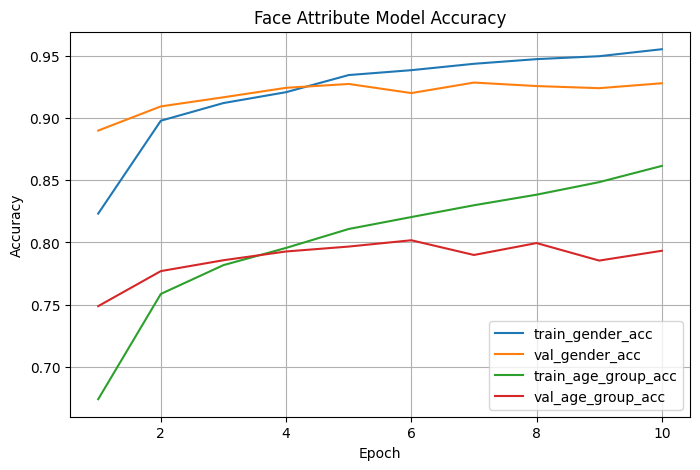

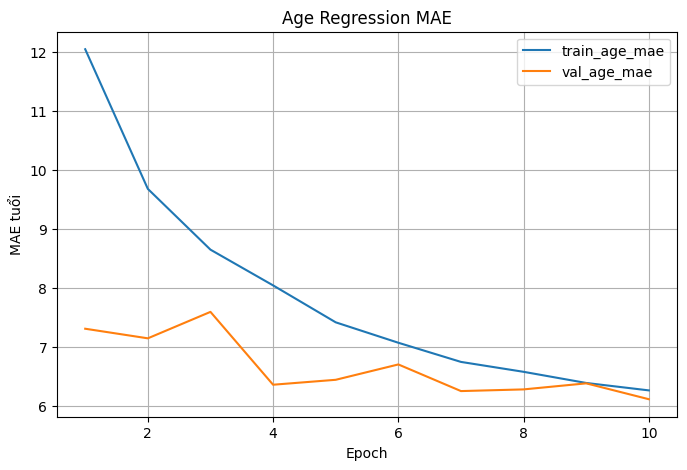

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(df_history["epoch"], df_history["train_gender_acc"], label="train_gender_acc")
plt.plot(df_history["epoch"], df_history["val_gender_acc"], label="val_gender_acc")
plt.plot(df_history["epoch"], df_history["train_age_group_acc"], label="train_age_group_acc")
plt.plot(df_history["epoch"], df_history["val_age_group_acc"], label="val_age_group_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Face Attribute Model Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(df_history["epoch"], df_history["train_age_mae"], label="train_age_mae")
plt.plot(df_history["epoch"], df_history["val_age_mae"], label="val_age_mae")
plt.xlabel("Epoch")
plt.ylabel("MAE tuổi")
plt.title("Age Regression MAE")
plt.legend()
plt.grid(True)
plt.show()

# 19

In [20]:
checkpoint = torch.load(
    best_attr_model_path,
    map_location=device,
    weights_only=False
)

best_model = FaceAttributeModel(
    num_age_groups=len(checkpoint["age_group_order"]),
    num_genders=2
).to(device)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

print("Loaded:", best_attr_model_path)
print("Best epoch:", checkpoint["epoch"])
print("Val gender acc:", checkpoint["val_gender_acc"])
print("Val age group acc:", checkpoint["val_age_group_acc"])
print("Val age MAE:", checkpoint["val_age_mae"])

test_result = evaluate(best_model, test_loader, device)

print("Test gender acc:", test_result["gender_acc"])
print("Test age group acc:", test_result["age_group_acc"])
print("Test age MAE:", test_result["age_mae"])

Loaded: C:\Users\Hoannd\Downloads\data_face\models\face_attribute_mobilenetv3_best.pth
Best epoch: 8
Val gender acc: 0.9254780652418447
Val age group acc: 0.7994938132733408
Val age MAE: 6.28726


Test gender acc: 0.9218442507731234
Test age group acc: 0.7973010964295755
Test age MAE: 6.464812


# 20

In [21]:
print(classification_report(
    test_result["gender_true"],
    test_result["gender_pred"],
    target_names=["male", "female"],
    digits=4
))

cm_gender = confusion_matrix(
    test_result["gender_true"],
    test_result["gender_pred"]
)

cm_gender_df = pd.DataFrame(
    cm_gender,
    index=["true_male", "true_female"],
    columns=["pred_male", "pred_female"]
)

display(cm_gender_df)

              precision    recall  f1-score   support

        male     0.9444    0.9037    0.9236      1859
      female     0.8993    0.9417    0.9200      1698

    accuracy                         0.9218      3557
   macro avg     0.9218    0.9227    0.9218      3557
weighted avg     0.9229    0.9218    0.9219      3557



,pred_male,pred_female
true_male,1680,179
true_female,99,1599


# 21

In [22]:
print(classification_report(
    test_result["age_group_true"],
    test_result["age_group_pred"],
    target_names=age_group_order,
    digits=4
))

cm_age = confusion_matrix(
    test_result["age_group_true"],
    test_result["age_group_pred"]
)

cm_age_df = pd.DataFrame(
    cm_age,
    index=[f"true_{x}" for x in age_group_order],
    columns=[f"pred_{x}" for x in age_group_order]
)

display(cm_age_df)

              precision    recall  f1-score   support

       child     0.9246    0.9336    0.9291       512
        teen     0.7027    0.2938    0.4143       177
       adult     0.8406    0.9019    0.8701      1783
  middle_age     0.6210    0.5718    0.5954       682
      senior     0.7247    0.7643    0.7440       403

    accuracy                         0.7973      3557
   macro avg     0.7627    0.6931    0.7106      3557
weighted avg     0.7906    0.7973    0.7890      3557



,pred_child,pred_teen,pred_adult,pred_middle_age,pred_senior
true_child,478,7,25,0,2
true_teen,30,52,94,1,0
true_adult,7,13,1608,152,3
true_middle_age,2,2,176,390,112
true_senior,0,0,10,85,308


# 22

In [23]:
age_true = test_result["age_true"]
age_pred = test_result["age_pred"]

age_mae = np.mean(np.abs(age_true - age_pred))
age_rmse = np.sqrt(np.mean((age_true - age_pred) ** 2))

print("Age MAE:", age_mae)
print("Age RMSE:", age_rmse)

df_age_error = pd.DataFrame({
    "true_age": age_true,
    "pred_age": age_pred,
    "abs_error": np.abs(age_true - age_pred)
})

display(df_age_error.describe())

Age MAE: 6.464812
Age RMSE: 8.674484


,true_age,pred_age,abs_error
count,3557.000000,3557.000000,3557.000000
mean,33.232220,34.595234,6.464812
std,19.904781,17.837559,5.784661
min,1.000000,0.000000,0.003580
25%,23.000000,24.936066,2.159904
50%,29.000000,31.199160,4.938599
75%,45.000000,43.574352,9.070786
max,116.000000,100.000000,59.331474


# 23

In [24]:
def predict_attribute_image(image_path, model, transform, device):
    img = Image.open(image_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)
    
    model.eval()
    
    with torch.no_grad():
        outputs = model(x)
        
        gender_prob = torch.softmax(outputs["gender"], dim=1)[0].detach().cpu().numpy()
        age_group_prob = torch.softmax(outputs["age_group"], dim=1)[0].detach().cpu().numpy()
        age_pred = float(outputs["age"][0].detach().cpu().numpy() * 100.0)
    
    gender_idx = int(np.argmax(gender_prob))
    age_group_idx = int(np.argmax(age_group_prob))
    
    age_pred = max(0, min(100, age_pred))
    
    return {
        "gender": gender_to_label[gender_idx],
        "gender_conf": float(gender_prob[gender_idx]),
        "age_group": idx_to_age_group[age_group_idx],
        "age_group_conf": float(age_group_prob[age_group_idx]),
        "age": round(age_pred, 1),
    }

# 24

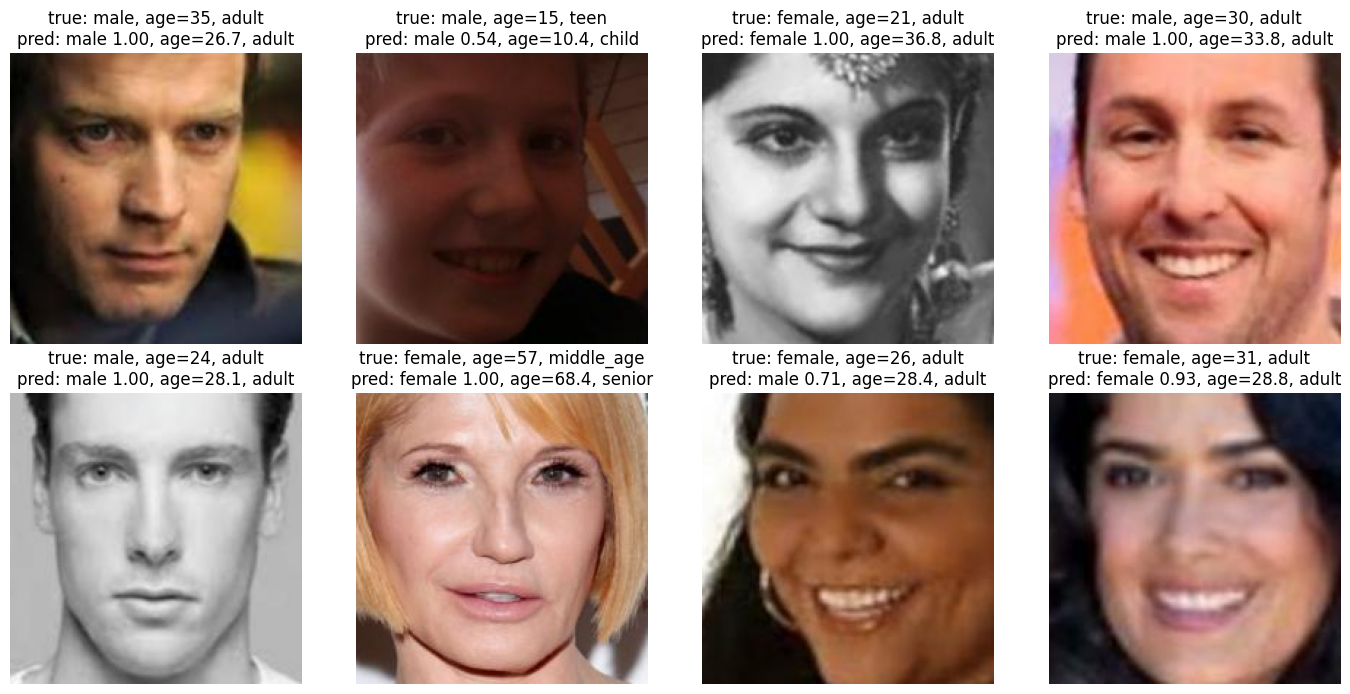

In [25]:
sample_df = df_test.sample(min(8, len(df_test)), random_state=42)

plt.figure(figsize=(14, 7))

for i, row in enumerate(sample_df.itertuples(), 1):
    result = predict_attribute_image(
        row.path,
        best_model,
        eval_tfms,
        device
    )
    
    img = Image.open(row.path).convert("RGB")
    
    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"true: {row.gender_label}, age={row.age}, {row.age_group}\n"
        f"pred: {result['gender']} {result['gender_conf']:.2f}, "
        f"age={result['age']}, {result['age_group']}"
    )

plt.tight_layout()
plt.show()

# 25

In [26]:
import json

attr_config = {
    "module": "face_image_attribute_analysis",
    "model_name": "face_attribute_mobilenetv3",
    "model_path": str(best_attr_model_path),
    "img_size": IMG_SIZE,
    "gender_labels": {
        "0": "male",
        "1": "female"
    },
    "age_group_order": age_group_order,
    "has_age_regression": True,
    "test_gender_acc": float(test_result["gender_acc"]),
    "test_age_group_acc": float(test_result["age_group_acc"]),
    "test_age_mae": float(test_result["age_mae"]),
    "note": "POC model trained on UTKFace. Predicts gender, age_group, and approximate age."
}

attr_config_path = MODEL_DIR / "face_attribute_config.json"

with open(attr_config_path, "w", encoding="utf-8") as f:
    json.dump(attr_config, f, ensure_ascii=False, indent=2)

print("Saved:", attr_config_path)
attr_config

Saved: C:\Users\Hoannd\Downloads\data_face\models\face_attribute_config.json


{'module': 'face_image_attribute_analysis',
 'model_name': 'face_attribute_mobilenetv3',
 'model_path': 'C:\\Users\\Hoannd\\Downloads\\data_face\\models\\face_attribute_mobilenetv3_best.pth',
 'img_size': 224,
 'gender_labels': {'0': 'male', '1': 'female'},
 'age_group_order': ['child', 'teen', 'adult', 'middle_age', 'senior'],
 'has_age_regression': True,
 'test_gender_acc': 0.9218442507731234,
 'test_age_group_acc': 0.7973010964295755,
 'test_age_mae': 6.4648118019104,
 'note': 'POC model trained on UTKFace. Predicts gender, age_group, and approximate age.'}

# 26

In [27]:
import cv2

def predict_attribute_from_face_crop_pil(face_pil, model, transform, device):
    x = transform(face_pil.convert("RGB")).unsqueeze(0).to(device)
    
    model.eval()
    
    with torch.no_grad():
        outputs = model(x)
        
        gender_prob = torch.softmax(outputs["gender"], dim=1)[0].detach().cpu().numpy()
        age_prob = torch.softmax(outputs["age_group"], dim=1)[0].detach().cpu().numpy()
    
    gender_idx = int(np.argmax(gender_prob))
    age_idx = int(np.argmax(age_prob))
    
    return {
        "gender": gender_to_label[gender_idx],
        "gender_conf": float(gender_prob[gender_idx]),
        "age_group": idx_to_age_group[age_idx],
        "age_group_conf": float(age_prob[age_idx])
    }